# 4. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [71]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* 2 different classification models, one of which must be **logistic regression**.
* A discussion of which **performance metric** is most relevant for the evaluation of your models.
* 2 different **validation methodologies** used to tune hyperparameters.
* **Confusion matrices** for your models, and associated comments.

### Data Cleansing

In [85]:
# check for nulls
print(df.isnull().sum())

# drop irrelevant/too null columns
data = df.drop(['stem-root', 'stem-surface', 'veil-type', 'veil-color', 'spore-print-color'], axis='columns')

data = data.drop_duplicates()

# these ones had an unknown = blank category in teh dataset
data['gill-attachment'].fillna('unknown', inplace = True)
data['ring-type'].fillna('unknown', inplace = True)

# these are just invalid
for column in ['cap-surface', 'gill-spacing']:
    data[column].fillna(data[column].mode()[0], inplace = True)


class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64


C:\Users\Anna\AppData\Local\Temp\ipykernel_4240\3178631137.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['gill-attachment'].fillna('unknown', inplace = True)
C:\Users\Anna\AppData\Local\Temp\ipykernel_4240\3178631137.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



### Encoding

In [73]:
# binary
data['class'] = data['class'].map({'e': 1, 'p': 0})
data['does-bruise-or-bleed'] = data['does-bruise-or-bleed'].map({'t': 1, 'f' : 0})
data['has-ring'] = data['has-ring'].map({'t': 1, 'f' : 0})

# strings
categories = [
    'cap-shape', 'cap-surface', 'cap-color', 'gill-attachment', 
    'gill-spacing', 'gill-color', 'stem-color',
    'ring-type', 'habitat', 'season'
]

data = pd.get_dummies(data, columns=categories, drop_first=True)

### Scaling

In [74]:
from sklearn.preprocessing import StandardScaler

numericals = ['cap-diameter', 'stem-height', 'stem-width']
scaler = StandardScaler()
data[numericals] = scaler.fit_transform(data[numericals])

### Analyzing Correlation

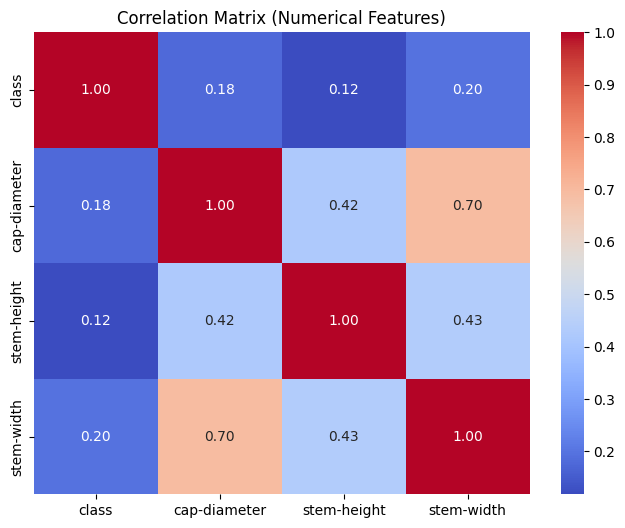

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ['class', 'cap-diameter', 'stem-height', 'stem-width']
corr_matrix = data[numerical_columns].corr()

# Plot the correlation matrix for numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f')
plt.show()

### Splitting Data

In [75]:
from sklearn.model_selection import train_test_split

features = data.drop('class', axis = 1)
label = data['class']

X_train, X_test, y_train, y_test = train_test_split(features, label, test_size = 0.2, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train.head()

,cap-diameter,does-bruise-or-bleed,stem-height,stem-width,has-ring,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_unknown,gill-attachment_x,gill-spacing_d,gill-spacing_f,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_unknown,ring-type_z,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
50673,-0.717858,0,-0.421946,-0.138429,0,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10383,-0.626749,0,-0.680972,-0.872207,0,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
48655,1.971767,0,2.302299,4.969106,0,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19906,-0.167405,0,0.256882,-0.401632,0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
57166,0.787345,0,-0.552948,0.811694,1,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Performance Metrics
These models are intended to predict whether or not the mushrooms in the dataset are edible. Considering the worst case scenario in which someone eats a mushroom that was incorrectly predicted to be edible (edible = 1/true, poisonous = 0/false), we want to focus on avoiding false positives, which means focusing on precision.

### 5-Fold CV + Logistic Regressor

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter = 1000, random_state = 42)

# hyperparameters
grid_values = {'penalty': ['l2'], 'C': [0.001,0.01,0.1,1,10,100,1000]}
grid_search = GridSearchCV(estimator = model, param_grid = grid_values, cv = 5, n_jobs = -1, scoring = 'precision')

grid_search.fit(X_train, y_train)
print(f"best parameters - \n{grid_search.best_params_}")

model = grid_search.best_estimator_
model.fit(X_train, y_train)
predictions = model.predict(X_val)
print(f"\nhyperparam tuning report - \n{classification_report(y_val, predictions)}")

# testing
test_predictions = model.predict(X_test)
print(f"\ntest report - \n{classification_report(y_test, test_predictions)}")

best parameters - 
{'C': 0.1, 'penalty': 'l2'}

hyperparam tuning report - 
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      5343
           1       0.75      0.77      0.76      4405

    accuracy                           0.78      9748
   macro avg       0.78      0.78      0.78      9748
weighted avg       0.78      0.78      0.78      9748


test report - 
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      6820
           1       0.74      0.77      0.76      5365

    accuracy                           0.78     12185
   macro avg       0.78      0.78      0.78     12185
weighted avg       0.78      0.78      0.78     12185



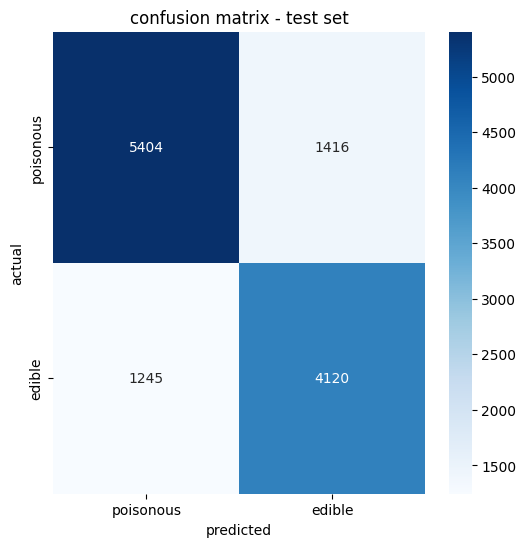

In [ ]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['poisonous', 'edible'], yticklabels=['poisonous', 'edible'])
plt.title('confusion matrix - test set')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

### Stratified KFold CV + Random Forest Classifier

In [78]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state = 42)
grid_values = {
    'n_estimators': [10, 30],
    'max_depth': [1, 10],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4]
}

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator = model, param_grid = grid_values, cv = skf, n_jobs = -1, scoring = 'precision')

grid_search.fit(X_train, y_train)
print(f"best parameters - \n{grid_search.best_params_}")

model = grid_search.best_estimator_
model.fit(X_train, y_train)
predictions = model.predict(X_val)
print(f"\nhyperparam tuning report - \n{classification_report(y_val, predictions)}")

# testing
test_predictions = model.predict(X_test)
print(f"\ntest report - \n{classification_report(y_test, test_predictions)}")

best parameters - 
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 30}

hyperparam tuning report - 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5343
           1       0.97      0.96      0.97      4405

    accuracy                           0.97      9748
   macro avg       0.97      0.97      0.97      9748
weighted avg       0.97      0.97      0.97      9748


test report - 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      6820
           1       0.96      0.96      0.96      5365

    accuracy                           0.97     12185
   macro avg       0.97      0.97      0.97     12185
weighted avg       0.97      0.97      0.97     12185

